In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.mixture import GaussianMixture
from datetime import timedelta

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA

pd.set_option('max_columns', None)


### Data prepairing

In [3]:
# import data

df = pd.read_csv('4_d_search_v_u2i_v_fav_block_no_cat.csv')

df_by_day = pd.read_csv('data_by_day.csv')

df_contacts = pd.read_csv('contacts.csv')

bad_categories = [
###
]

df_by_day = df_by_day[~df_by_day['category'].isin(bad_categories)]
df = df[~df['category'].isin(bad_categories)]


In [4]:
# type casting

df['start_session_date'] = pd.to_datetime(df['start_session_date'])
df['min_contact_date'] = pd.to_datetime(df['min_contact_date'])
df['min_view_date'] = pd.to_datetime(df['min_view_date'])

df['hours_to_contact'] = (df['min_contact_date'] -
                          df['min_view_date']).astype('timedelta64[h]')

df['prev_session_date'] = df.groupby(['buyer_id', 'category']).start_session_date.shift(1)
df['days_from_prev_session'] = (df['start_session_date'] - df['prev_session_date']).dt.days

df['days_from_prev_session'] = df['days_from_prev_session'].fillna(0).astype('int64')


In [5]:
columns_to_seg = [
### Columns for model
]

columns_to_scale = [
### Columns for model
]

columns_to_scale_by_day = [
### Columns for model
]

columns_to_analyze = [
### Columns for model
]

In [6]:
# Sessions with contact the same day

df[
    df['start_session_date'] == df['min_view_date'].dt.
    date].shape[0] / df[~df['min_contact_date'].isna()].shape[0]

0.6311517277192743

In [89]:
df_contacts = df_contacts[df_contacts['hours_from_view_to_first_contact'] >= 0]

### EDA

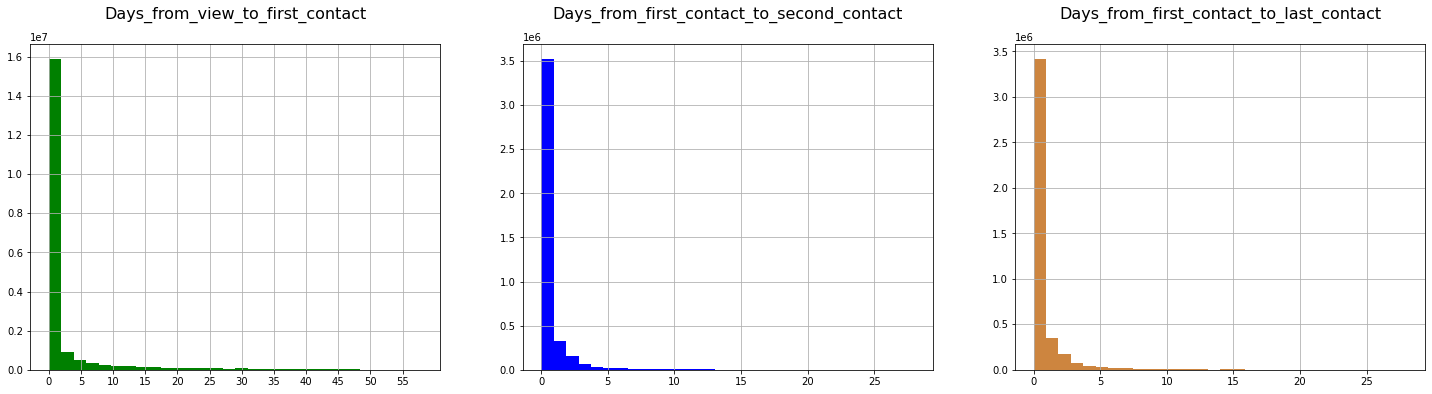

In [131]:
# Viz for days to contact

fig, axs = plt.subplots(1, 3)

fig.set_figheight(6)
fig.set_figwidth(25)

axs[0].hist(x=df_contacts.hours_from_view_to_first_contact.floordiv(24),
              bins=30, color='green')
axs[0].set_title('Days_from_view_to_first_contact\n', fontsize=16)
axs[0].set_xticks([i for i in range(0, 60, 5)])

axs[1].hist(x=df_contacts.hours_from_first_contact_to_second_contact.floordiv(24),
              bins=30, color='blue')
axs[1].set_title('Days_from_first_contact_to_second_contact\n', fontsize=16)
axs[1].set_xticks([i for i in range(0, 30, 5)])

axs[2].hist(x=df_contacts.hours_from_first_contact_to_last_contact.floordiv(24),
              bins=30, color='peru')
axs[2].set_title('Days_from_first_contact_to_last_contact\n', fontsize=16)
axs[2].set_xticks([i for i in range(0, 30, 5)])


for ax in axs.flat:
    ax.grid(True)

In [11]:
# Days in sessions distib

df_clean.days.value_counts(normalize=True).mul(100).round(2).astype('str') + '%'


1    93.9%
2    5.48%
3    0.56%
4    0.06%
Name: days, dtype: object

In [12]:
# "Попали в сессию"

df_clean[df_clean['start_session_date'] <= df_clean['min_view_date'].dt.
   date].shape[0] / df_clean[~df_clean['min_contact_date'].isna()].shape[0]


0.6628942084942085

/var/folders/jb/h48r1pr51vn7mtp9zqx97vdw0000gn/T/ipykernel_6122/4010701910.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['miss'] = (sub_df['start_session_date'].dt.date - sub_df['min_view_date'].dt.date).dt.days


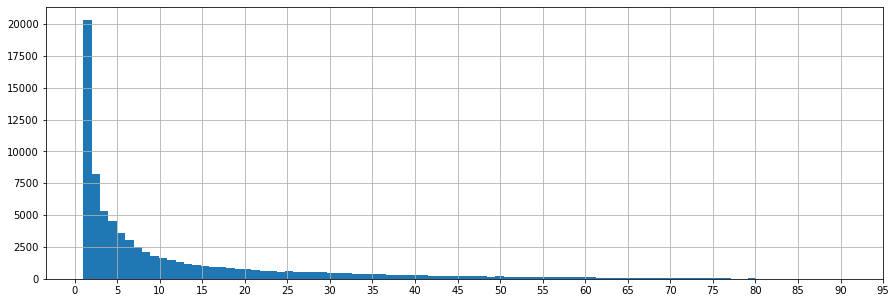

In [271]:
# Misses distribution

sub_df = df[~df['min_view_date'].isna()]

sub_df['miss'] = (sub_df['start_session_date'].dt.date - sub_df['min_view_date'].dt.date).dt.days

plt.figure(figsize=(15,5))
sub_df[sub_df['miss'] > 0].miss.hist(bins=88)
plt.xticks(np.arange(0,100,5))
plt.show()

In [401]:
# Sessions info

print('Сессий с хотя бы одним просмотром - {:.2f}%, c одним просмотром - {:.2f}% \n' \
        .format(df_clean[df_clean['views'] >= 1].shape[0]*100 / df_clean.shape[0],
        df_clean[df_clean['views'] == 1].shape[0]*100 / df_clean.shape[0]))

print('Сессии с только одним просмотром и активностью в других категориях - {:.2f}% \n'.format(
    df_clean[((df_clean['views'] == 1) & (df_clean['max_log_cat_cnt'] > 1) & (df_clean['searches'] == 0)
              & (df_clean['fav_add'] == 0) & (df_clean['profile_views'] == 0) & (df_clean['messages_sent'] == 0)
              & (df_clean['marketplace_click'] == 0)
              & (df_clean['target_uniq_contacts'] == 0))].shape[0]*100 \
         / df_clean.shape[0]))

print('Сессий с хотя бы одним поиском - {:.2f}%, c одним поиском - {:.2f}% \n' \
        .format(df_clean[df_clean['searches'] >= 1].shape[0]*100 / df_clean.shape[0],
        df_clean[df_clean['searches'] == 1].shape[0]*100 / df_clean.shape[0]))

Сессий с хотя бы одним просмотром - 91.81%, c одним просмотром - 37.54% 

Сессии с только одним просмотром и активностью в других категориях - 14.99% 

Сессий с хотя бы одним поиском - 53.38%, c одним поиском - 11.44% 



In [402]:
print('Сессий с хотя бы одним целевым контактом - {:.2f}%, c одним целевым контактом - {:.2f}% \n' \
        .format(df_clean[df_clean['target_uniq_contacts'] >= 1].shape[0]*100 / df_clean.shape[0],
        df_clean[df_clean['target_uniq_contacts'] == 1].shape[0]*100 / df_clean.shape[0]))

Сессий с хотя бы одним целевым контактом - 1.92%, c одним целевым контактом - 1.79% 



In [403]:
# Contacts in 1 session

df_clean[
    df_clean['target_uniq_contacts'] >= 1].target_uniq_contacts.value_counts(
        normalize=True).mul(100).round(2).astype('str') + '%'

1    93.53%
2     5.72%
3     0.61%
4      0.1%
5     0.03%
6     0.01%
7      0.0%
8      0.0%
Name: target_uniq_contacts, dtype: object

In [404]:
# Same items views after contacts

print(str((df.self_item_views.sum() / df.views.sum()) * 100), '%')

0.4064467489278846 %


### Overlap of intraday searches by category

In [4]:
# Понимаем, стоит ли объединять логические категории - близкие по смыслу д.б. значимо больше чем нелогичные

df_short = df_by_day[df_by_day['searches'] > 0][['event_date', 'category', 'buyer_id']]

merged_df = df_short.merge(df_short, on=['event_date', 'buyer_id'], how='left')
merged_df = merged_df[merged_df['category_x'] != merged_df['category_y']]

def get_unique_ordered_pairs(group):
    pairs = set()
    for x, y in zip(group['category_x'], group['category_y']):
        pairs.add(tuple(sorted((x, y))))
    return list(pairs)

grouped = merged_df.groupby(['event_date', 'buyer_id']).apply(get_unique_ordered_pairs).reset_index() \
            .rename(columns={0:'search_categ'})

grouped_exp_paids = pd.DataFrame(grouped.explode('search_categ').reset_index(drop=True).search_categ.value_counts()  \
             / df_short.shape[0])

grouped_exp_paids['cum_sum'] = grouped_exp_paids['search_categ'].cumsum()

grouped_exp_paids.head(20)


### Feature Correlation

In [5]:
# corr_matrix = df_clean[columns_to_scale].corr()

# # Построение тепловой карты

# plt.figure(figsize=(15, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
# plt.xticks(rotation=75)
# plt.title('Correlation Heatmap')
# plt.show()

In [363]:
# temp_df = df_clean[columns_to_seg]

# X_sess = temp_df.values


# scaler = MinMaxScaler()

# X_scaled = scaler.fit_transform(X_sess)

# temp_df.loc[:, columns_to_seg] = X_scaled


# sns.pairplot(temp_df)
# plt.suptitle("Scatter plots for feature pairs", y=1.02)
# plt.show()

## Clustering

### Determining the number of clusters

Методы оценки:

**Inertia (Sum of Squared Distances)**:  
Мера, используемая в K-means для оценки качества кластеризации. Меньшее значение указывает на более плотные кластеры.

**Силуэтный коэффициент (Silhouette Score)**:  
Оценивает, насколько хорошо каждый объект находится в своем кластере по сравнению с другими кластерами. 
 

**Davies-Bouldin Index**:
Среднее расстояние между кластерами по отношению к их размерам. Чем меньше значение, тем лучше разделение между кластерами.  

<!-- **Метод BIC**:
Штрафует многочисленные нормальные распределения и пытается сохранить модель достаточно простой, чтобы она описывала заданный паттерн.

Следовательно, можно прогнать алгоритм GMM для большого количества кластерных центров, и значение BIC вырастет до какой-то точки, а затем начнёт снижаться по мере роста штрафа. -->

#### Min-max normalization

In [371]:
X_short = df_clean[columns_to_seg].sample(100000).values

In [372]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_short)

In [373]:
km_scores = []
km_silhouette = []
db_score = []

for i in range(2, 13):
    km = KMeans(n_clusters=i, random_state=0).fit(X_scaled)

#     print("Score for number of cluster(s) {}: {}".format(i, km.inertia_))
    km_scores.append(km.inertia_)

    silhouette = silhouette_score(X_scaled, km.labels_)
    km_silhouette.append(silhouette)
#     print("Silhouette score for number of cluster(s) {}: {}".format(
#         i, silhouette))

    db = davies_bouldin_score(X_scaled, km.labels_)
    db_score.append(db)
#     print("Davies Bouldin score for number of cluster(s) {}: {}".format(i, db))

#     print('--------------------------------------------\n')
    

# gm_bic = []
# gm_score = []

# for i in range(2, 13):
#     gm = GaussianMixture(n_components=i, n_init=10, tol=1e-3,
#                          max_iter=1000).fit(X_scaled)
# #     print("BIC for number of cluster(s) {}: {}".format(i,
# #                                                        gm.bic(
# #                                                            X_scaled)))
# #     print("Log-likelihood score for number of cluster(s) {}: {}".format(
# #         i, gm.score(X_scaled)))
# #     print("-" * 100)
#     gm_bic.append(-gm.bic(X_scaled))
#     gm_score.append(gm.score(X_scaled))

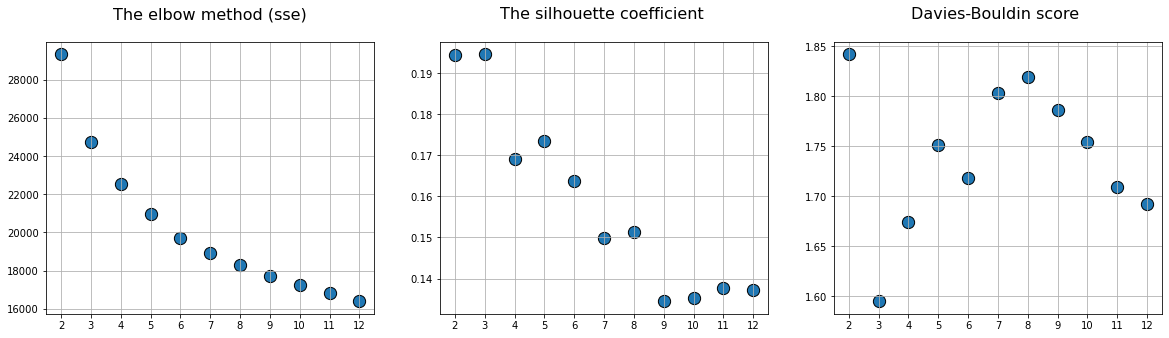

In [382]:
fig, axs = plt.subplots(1, 3)

fig.set_figheight(5)
fig.set_figwidth(20)

axs[0].scatter(x=[i for i in range(2, 13)],
                  y=km_scores,
                  s=150,
                  edgecolor='k')
axs[0].set_title("The elbow method (sse)\n", fontsize=16)
axs[0].set_xticks([i for i in range(2, 13)])

axs[1].scatter(x=[i for i in range(2, 13)],
                  y=km_silhouette,
                  s=150,
                  edgecolor='k')
axs[1].set_title("The silhouette coefficient \n", fontsize=16)
axs[1].set_xticks([i for i in range(2, 13)])

axs[2].scatter(x=[i for i in range(2, 13)],
                  y=db_score,
                  s=150,
                  edgecolor='k')
axs[2].set_title("Davies-Bouldin score \n", fontsize=16)
axs[2].set_xticks([i for i in range(2, 13)])

# axs[1, 1].scatter(x=[i for i in range(2, 13)],
#                   y=np.log(gm_bic),
#                   s=150,
#                   edgecolor='k')
# axs[1, 1].set_title("The Gaussian Mixture model BIC \n", fontsize=16)
# axs[1, 1].set_xticks([i for i in range(2, 13)])

for ax in axs.flat:
    ax.grid(True)

#### StandardScaler normalization

In [387]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_short)

In [388]:
km_scores = []
km_silhouette = []
db_score = []

for i in range(2, 13):
    km = KMeans(n_clusters=i, random_state=0).fit(X_scaled)

#     print("Score for number of cluster(s) {}: {}".format(i, km.inertia_))
    km_scores.append(km.inertia_)

    silhouette = silhouette_score(X_scaled, km.labels_)
    km_silhouette.append(silhouette)
#     print("Silhouette score for number of cluster(s) {}: {}".format(
#         i, silhouette))

    db = davies_bouldin_score(X_scaled, km.labels_)
    db_score.append(db)
#     print("Davies Bouldin score for number of cluster(s) {}: {}".format(i, db))

#     print('--------------------------------------------\n')
    

# gm_bic = []
# gm_score = []

# for i in range(2, 13):
#     gm = GaussianMixture(n_components=i, n_init=10, tol=1e-3,
#                          max_iter=1000).fit(X_scaled)
# #     print("BIC for number of cluster(s) {}: {}".format(i,
# #                                                        gm.bic(
# #                                                            X_scaled)))
# #     print("Log-likelihood score for number of cluster(s) {}: {}".format(
# #         i, gm.score(X_scaled)))
# #     print("-" * 100)
#     gm_bic.append(-gm.bic(X_scaled))
#     gm_score.append(gm.score(X_scaled))

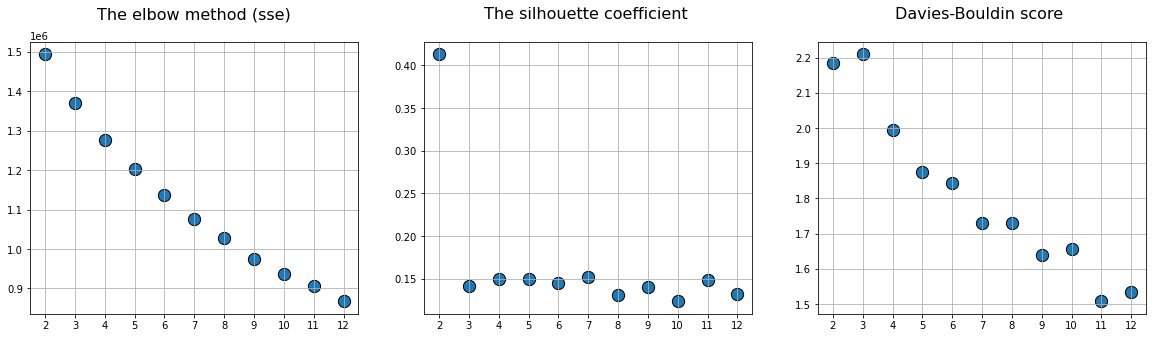

In [389]:
fig, axs = plt.subplots(1, 3)

fig.set_figheight(5)
fig.set_figwidth(20)

axs[0].scatter(x=[i for i in range(2, 13)],
                  y=km_scores,
                  s=150,
                  edgecolor='k')
axs[0].set_title("The elbow method (sse)\n", fontsize=16)
axs[0].set_xticks([i for i in range(2, 13)])

axs[1].scatter(x=[i for i in range(2, 13)],
                  y=km_silhouette,
                  s=150,
                  edgecolor='k')
axs[1].set_title("The silhouette coefficient \n", fontsize=16)
axs[1].set_xticks([i for i in range(2, 13)])

axs[2].scatter(x=[i for i in range(2, 13)],
                  y=db_score,
                  s=150,
                  edgecolor='k')
axs[2].set_title("Davies-Bouldin score \n", fontsize=16)
axs[2].set_xticks([i for i in range(2, 13)])

# axs[1, 1].scatter(x=[i for i in range(2, 13)],
#                   y=np.log(gm_bic),
#                   s=150,
#                   edgecolor='k')
# axs[1, 1].set_title("The Gaussian Mixture model BIC \n", fontsize=16)
# axs[1, 1].set_xticks([i for i in range(2, 13)])

for ax in axs.flat:
    ax.grid(True)

#### W/o normalization

In [390]:
km_scores = []
km_silhouette = []
db_score = []

for i in range(2, 13):
    km = KMeans(n_clusters=i, random_state=0).fit(X_short)

#     print("Score for number of cluster(s) {}: {}".format(i, km.inertia_))
    km_scores.append(km.inertia_)

    silhouette = silhouette_score(X_short, km.labels_)
    km_silhouette.append(silhouette)
#     print("Silhouette score for number of cluster(s) {}: {}".format(
#         i, silhouette))

    db = davies_bouldin_score(X_short, km.labels_)
    db_score.append(db)
#     print("Davies Bouldin score for number of cluster(s) {}: {}".format(i, db))

#     print('--------------------------------------------\n')
    

# gm_bic = []
# gm_score = []

# for i in range(2, 13):
#     gm = GaussianMixture(n_components=i, n_init=10, tol=1e-3,
#                          max_iter=1000).fit(X_short)
# # #     print("BIC for number of cluster(s) {}: {}".format(i,
# # #                                                        gm.bic(
# # #                                                            X_short)))
# # #     print("Log-likelihood score for number of cluster(s) {}: {}".format(
# # #         i, gm.score(X_short)))
# # #     print("-" * 100)
#     gm_bic.append(-gm.bic(X_short))
#     gm_score.append(gm.score(X_short))

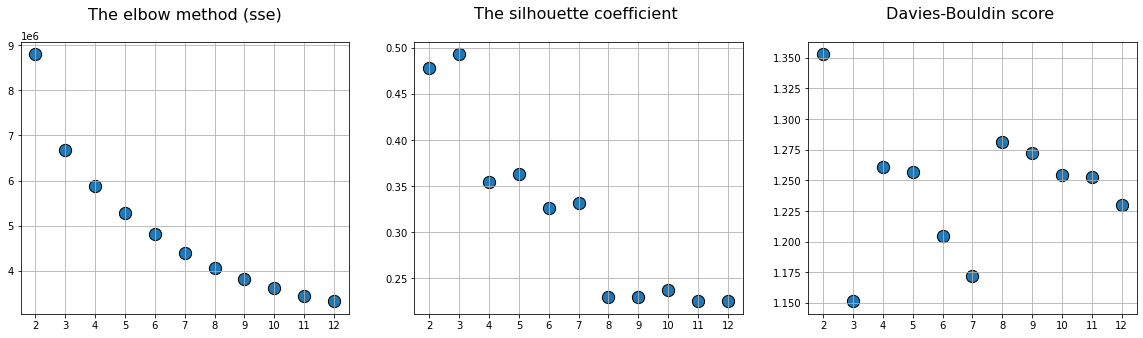

In [391]:
fig, axs = plt.subplots(1, 3)

fig.set_figheight(5)
fig.set_figwidth(20)

axs[0].scatter(x=[i for i in range(2, 13)],
                  y=km_scores,
                  s=150,
                  edgecolor='k')
axs[0].set_title("The elbow method (sse)\n", fontsize=16)
axs[0].set_xticks([i for i in range(2, 13)])

axs[1].scatter(x=[i for i in range(2, 13)],
                  y=km_silhouette,
                  s=150,
                  edgecolor='k')
axs[1].set_title("The silhouette coefficient \n", fontsize=16)
axs[1].set_xticks([i for i in range(2, 13)])

axs[2].scatter(x=[i for i in range(2, 13)],
                  y=db_score,
                  s=150,
                  edgecolor='k')
axs[2].set_title("Davies-Bouldin score \n", fontsize=16)
axs[2].set_xticks([i for i in range(2, 13)])

# axs[1, 1].scatter(x=[i for i in range(2, 13)],
#                   y=np.log(gm_bic),
#                   s=150,
#                   edgecolor='k')
# axs[1, 1].set_title("The Gaussian Mixture model BIC \n", fontsize=16)
# axs[1, 1].set_xticks([i for i in range(2, 13)])

for ax in axs.flat:
    ax.grid(True)

#### Standardization by category

In [392]:
final_norm_df = pd.DataFrame(columns=df_clean.columns)

for cat in df_clean.category.unique():
    scaler = MinMaxScaler()
    temp_df = df_clean[df_clean['category'] == cat]
    X_temp = temp_df[columns_to_seg].values
    X_temp_scaled = scaler.fit_transform(X_temp)
    temp_df.loc[:, columns_to_seg] = X_temp_scaled
    final_norm_df = pd.concat([final_norm_df, temp_df])
    

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/indexing.py:1835: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/indexing.py:1835: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/indexing.py:1835: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [393]:
sample_df = final_norm_df.sample(100000)

X_scaled = sample_df[columns_to_seg].values

In [394]:
km_scores= []
km_silhouette = []
db_score = []

for i in range(2,12):
    km = KMeans(n_clusters=i, random_state=42).fit(X_scaled)
    
#     print("Score for number of cluster(s) {}: {}".format(i,km.inertia_))
    km_scores.append(km.inertia_)
    
    silhouette = silhouette_score(X_scaled,km.labels_)
    km_silhouette.append(silhouette)
#     print("Silhouette score for number of cluster(s) {}: {}".format(i,silhouette))
    
    db = davies_bouldin_score(X_scaled,km.labels_)
    db_score.append(db)
#     print("Davies Bouldin score for number of cluster(s) {}: {}".format(i,db))

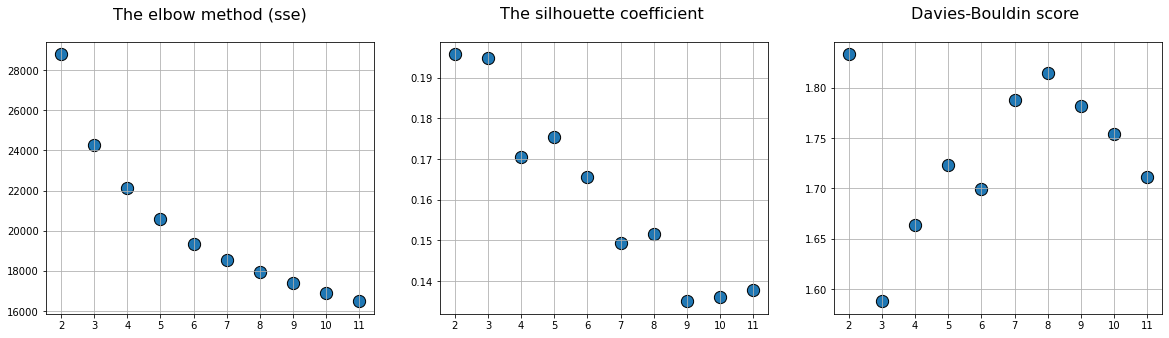

In [395]:
fig, axs = plt.subplots(1, 3)

fig.set_figheight(5)
fig.set_figwidth(20)

axs[0].scatter(x=[i for i in range(2, 12)],
                  y=km_scores,
                  s=150,
                  edgecolor='k')
axs[0].set_title("The elbow method (sse)\n", fontsize=16)
axs[0].set_xticks([i for i in range(2, 12)])

axs[1].scatter(x=[i for i in range(2, 12)],
                  y=km_silhouette,
                  s=150,
                  edgecolor='k')
axs[1].set_title("The silhouette coefficient \n", fontsize=16)
axs[1].set_xticks([i for i in range(2, 12)])

axs[2].scatter(x=[i for i in range(2, 12)],
                  y=db_score,
                  s=150,
                  edgecolor='k')
axs[2].set_title("Davies-Bouldin score \n", fontsize=16)
axs[2].set_xticks([i for i in range(2, 12)])


for ax in axs.flat:
    ax.grid(True)

In [370]:
# X_sess = final_norm_df[columns_to_seg_by_day].values

# k_means_sess = KMeans(n_clusters=5, random_state=42).fit(X_sess)
# labels_sess = k_means_sess.labels_

# final_norm_df['cluster'] = labels_sess

# share_clusters = final_norm_df['cluster'].value_counts(normalize=True) \
# .mul(100).round(2).sort_index().astype('str') + '%'

# share_clusters


In [369]:
# share_actions = (final_norm_df.groupby('cluster')[columns_to_scale].agg('sum') \
# .apply(lambda x: x / x.sum()).mul(100).round(2).astype('str') + '%').reset_index()

# share_actions['share of cluster'] = share_clusters

# share_actions

In [368]:
# final_norm_df.groupby('cluster')[columns_to_seg].agg('mean').round(2)


### Building clusters

In [10]:
X_sess = df_clean[columns_to_seg].values


# scaler = MinMaxScaler()

# X_sess = scaler.fit_transform(X_sess)

In [11]:
k_means_sess = KMeans(n_clusters=7, random_state=42).fit(X_sess)
labels_sess = k_means_sess.labels_

df_clean['cluster'] = labels_sess


/var/folders/jb/h48r1pr51vn7mtp9zqx97vdw0000gn/T/ipykernel_7592/989653242.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['cluster'] = labels_sess


In [13]:
df_clean['cluster'] = np.where(df_clean['cluster'].isin([2,6]), 2, df_clean['cluster'])


/var/folders/jb/h48r1pr51vn7mtp9zqx97vdw0000gn/T/ipykernel_7592/1305469425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['cluster'] = np.where(df_clean['cluster'].isin([2,6]), 2, df_clean['cluster'])


In [14]:
# Sessions share in clusters

share_clusters = df_clean['cluster'].value_counts(normalize=True) \
.mul(100).round(2).sort_index().astype('str') + '%'

share_clusters

0     7.03%
1     7.19%
2    11.74%
3     8.41%
4    63.13%
5      2.5%
Name: cluster, dtype: object

In [16]:
# Sessions with target contact

share_df = df_clean.copy()

share_df['is_target_sess'] = np.where(share_df['target_uniq_contacts'] > 0, 1,
                                      0)

(share_df.groupby('cluster')[[
    'is_target_sess'
]].agg(lambda x: x.sum() / x.count()).mul(100).round(2).astype('str') + '%')

,is_target_sess
cluster,
0,4.19%
1,4.61%
2,1.26%
3,1.79%
4,1.11%
5,9.36%


In [21]:
# Final resulsts

df_to_exp = df_clean[['buyer_id', 'category', 'start_session_date', 'days', 'cluster']]

df_to_exp['end_session_date'] = df['start_session_date'] + pd.to_timedelta(df['days'] - 1, unit='d')

df_to_exp.sample(1000000).to_csv('muylobanov_clusterd_data_2.csv')

/var/folders/jb/h48r1pr51vn7mtp9zqx97vdw0000gn/T/ipykernel_7592/819389450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_exp['end_session_date'] = df['start_session_date'] + pd.to_timedelta(df['days'] - 1, unit='d')


Why scaling may work poorly — there are typical actions across all clusters, and by normalizing them we won't see the differences

In [19]:
temp_df = df_clean.groupby('cluster')[['target_uniq_contacts', 'target_delivery_contacts']].sum()

temp_df['target_delivery_contacts'] / temp_df['target_uniq_contacts']

cluster
0    0.188863
1    0.205964
2    0.203491
3    0.218306
4    0.215046
5    0.222565
dtype: float64

### Short sessions - cluster 4

In [22]:
sub_df = df_clean[df_clean['cluster'] == 4]

columns_to_view = [
### Columns for ML model
]

In [23]:
# Not in session

sub_df[
    sub_df['start_session_date'] > sub_df['min_view_date'].dt.
    date].shape[0] / sub_df[~sub_df['min_contact_date'].isna()].shape[0]

0.3603497203221626

In [24]:
# Hours to contact

sub_df[
    sub_df['start_session_date'] > sub_df['min_view_date'].dt.
    date].hours_to_contact.describe()

count    21968.000000
mean       231.772715
std        330.359065
min          0.000000
25%         30.000000
50%         93.000000
75%        269.000000
max       2064.000000
Name: hours_to_contact, dtype: float64

#### Cluster of origin of the target view

In [443]:
sub_df = df_clean[df_clean['start_session_date'] > df_clean['min_view_date'].dt.
   date]

sub_df['start_session_date'] = sub_df['min_view_date'].dt.date

df_clean['start_session_date'] = pd.to_datetime(df_clean['start_session_date']).dt.date

fn_sub_df = sub_df.merge(
    df_clean[['buyer_id', 'category', 'start_session_date',
              'cluster']],
    on=['buyer_id', 'category', 'start_session_date'])

/var/folders/jb/h48r1pr51vn7mtp9zqx97vdw0000gn/T/ipykernel_6122/3104810995.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['start_session_date'] = sub_df['min_view_date'].dt.date
/var/folders/jb/h48r1pr51vn7mtp9zqx97vdw0000gn/T/ipykernel_6122/3104810995.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['start_session_date'] = pd.to_datetime(df_clean['start_session_date']).dt.date


In [445]:
fn_sub_df[fn_sub_df['cluster_x'] == 5].cluster_y.value_counts(normalize=True).mul(100)

5    32.615786
1    22.994129
4    18.656230
0    17.938682
3     4.109589
2     3.685584
Name: cluster_y, dtype: float64

### Tuning model

#### Feature impact

In [364]:
X_sess = df_clean[columns_to_seg].values
y_sess = labels_sess

rfc = RandomForestClassifier(random_state=42)

x_train, x_test, y_train, y_test = train_test_split(X_sess, y_sess, test_size=0.25, random_state=42)


In [365]:
rfc1=RandomForestClassifier(random_state=42, max_features='auto', n_estimators= 200, max_depth=8, 
                            criterion='entropy')


rfc1.fit(x_train, y_train)

y_pred = rfc1.predict(x_test)

In [396]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred, average=None)
print(precision)

# Recall
recall = recall_score(y_test, y_pred, average=None)
print(recall)

# F1 score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)

# Roc-Auc score

roc_auc = roc_auc_score(y_test, rfc1.predict_proba(x_test), multi_class='ovr')
print(roc_auc)

[0.94652604 0.93943907 0.99895091 0.94680268 0.97841846 0.94570938
 0.97180338]
[0.94072694 0.87925427 0.99475855 0.88144576 0.9927517  0.94730125
 0.98924091]
[0.94361758 0.90835084 0.99685032 0.91295602 0.98553297 0.94650464
 0.98044462]
0.9989395094391138


In [7]:
# forest_importances = pd.Series(
#     rfc1.feature_importances_,
#     index=columns_to_seg).sort_values(ascending=False)

# plt.figure(figsize=(15, 10))
# sns.barplot(x=forest_importances.values,
#             y=forest_importances.index,
#             orient='h')
# plt.title("Feature importances using MDI")
# plt.show()

### Profitable segments

In [739]:
df_by_cluster = df_clean.groupby('cluster', as_index=False)['target_uniq_contacts'].sum() \
.rename(columns={'cluster':'cluster_n'})

df_by_cluster = pd.concat([df_by_cluster,
                           df_by_cluster[['target_uniq_contacts']].apply(lambda x: x / float(x.sum())) \
                            .rename(columns={'target_uniq_contacts':'share'}),
                           df_clean['cluster'].value_counts(normalize=True).round(2).sort_index()]
                          , axis=1)

df_by_cluster[
    'weight_tc_value'] = df_by_cluster['share'] / df_by_cluster['cluster']

df_by_cluster.query('cluster > 0.001').sort_values(by='weight_tc_value',
                                                   ascending=False)

,cluster_n,target_uniq_contacts,share,cluster,weight_tc_value
3,3,36455,0.189408,0.04,4.735203
0,0,34500,0.179251,0.07,2.560723
5,5,10819,0.056212,0.05,1.124239
2,2,22003,0.114320,0.11,1.039275
1,1,8046,0.041804,0.05,0.836087
4,4,80645,0.419005,0.67,0.625380


### PCA

In [348]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_short)


In [8]:
# pca = PCA().fit(X_scaled)
# explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# # График объясненной дисперсии

# plt.figure(figsize=(10, 5))
# plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Explained Variance by Number of Components')
# plt.grid(True)
# plt.show()

# # Определение оптимального числа компонент

# n_components = np.argmax(explained_variance_ratio >= 0.80) + 1 

# X_reduced = PCA(n_components=n_components).fit_transform(X_sess)

# kmeans = KMeans(n_clusters=7)  
# kmeans.fit(X_reduced)
# labels = kmeans.labels_

# silhouette_avg = silhouette_score(X_reduced, labels)
# print(f'Silhouette Score: {silhouette_avg}')

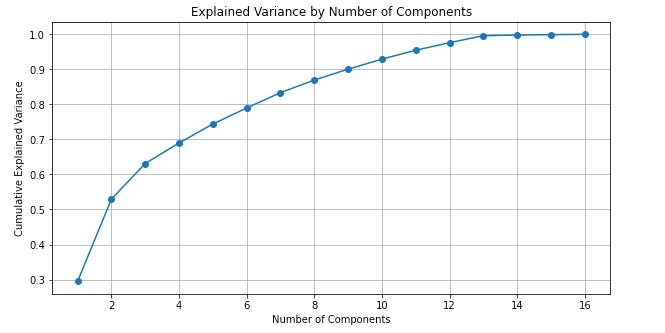